#### 멀티 에이전트

여러 개의 **에이전트**가 서로 **협력**하고 **상호작용**하여 **하나**의 복잡한 **목표**를 달성하는 아키텍처를 의미한다.

In [3]:
from langchain_core.tools import tool
import httpx
from geopy.geocoders import Nominatim
import json

def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")

@tool
def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

tools = [get_weather]

In [4]:
get_coordinates("부산")

(35.1799528, 129.0752365)

In [5]:
tools[0].invoke({"city_name": "부산"})

날씨 조회: 부산


'{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.039577484130859375, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "seconds", "temperature": "\\u00b0C", "windspeed": "km/h", "winddirection": "\\u00b0", "is_day": "", "weathercode": "wmo code"}, "current_weather": {"time": "2025-09-23T07:15", "interval": 900, "temperature": 23.5, "windspeed": 12.8, "winddirection": 50, "is_day": 1, "weathercode": 1}}'

In [6]:
from langgraph.prebuilt import ToolNode # 에이전트와 도구 간의 인터페이스 역할을 하며, 언어 모델의 지시에 따라 실제 도구 실행을 담당하는 핵심적인 중간 다리
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
load_dotenv()

# * 기상 전문가 서브 그래프 생성
def create_weather_agent():
    """날씨 관련 질문을 처리하는 전문가 서브그래프를 생성합니다."""
    model = ChatGoogleGenerativeAI(model="gemini-2.0-flash").bind_tools(tools)
    tool_node = ToolNode([get_weather])

    def call_model(state: MessagesState):
        return {"messages": [model.invoke(state["messages"])]}

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("call_model", call_model)
    graph_builder.add_node("tool_node", tool_node)

    graph_builder.add_edge(START, "call_model")
    graph_builder.add_conditional_edges(
        "call_model",
        lambda s: "tool_node" if s["messages"][-1].tool_calls else END,
        {"tool_node": "tool_node", END: END},
    )
    graph_builder.add_edge("tool_node", "call_model")
    return graph_builder.compile()

In [7]:
from typing import Literal

# * 라우터 생성
def router(state: MessagesState) -> Literal["weather_expert", "general_agent"]:
    query = state["messages"][-1].content.lower()
    if "날씨" in query or "기온" in query:
        print("라우팅 결정: 기상 전문가에게 위임")
        return "weather_expert"
    print("라우팅 결정: 일반 에이전트가 처리")
    return "general_agent"

In [8]:
# * 메인 그래프 생성
def create_main_agent(weather_subgraph):
    """질문을 라우팅하고 처리하는 메인 에이전트 그래프를 생성합니다."""
    main_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # 모델을 다르게 사용 가능

    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node(
        "general_agent", lambda s: {"messages": [main_model.invoke(s["messages"])]}
    )
    graph_builder.add_node("weather_expert", weather_subgraph)
    graph_builder.add_conditional_edges(
        START,
        router,
        {
            "weather_expert": "weather_expert",
            "general_agent": "general_agent",
        },
    )
    graph_builder.add_edge("general_agent", END)
    graph_builder.add_edge("weather_expert", END)
    return graph_builder.compile()

In [9]:
from IPython.display import Image, display

print("=== LangGraph 서브그래프 예제 (기상 전문가) ===\n")
weather_agent = create_weather_agent()
main_agent = create_main_agent(weather_agent)

# 그래프 이미지 로컬에 저장
# main_graph_image = main_agent.get_graph(xray=True).draw_mermaid_png()
# with open("main_agent_graph.png", "wb") as f:
#     f.write(main_graph_image)

try:
    display(Image(main_agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

=== LangGraph 서브그래프 예제 (기상 전문가) ===



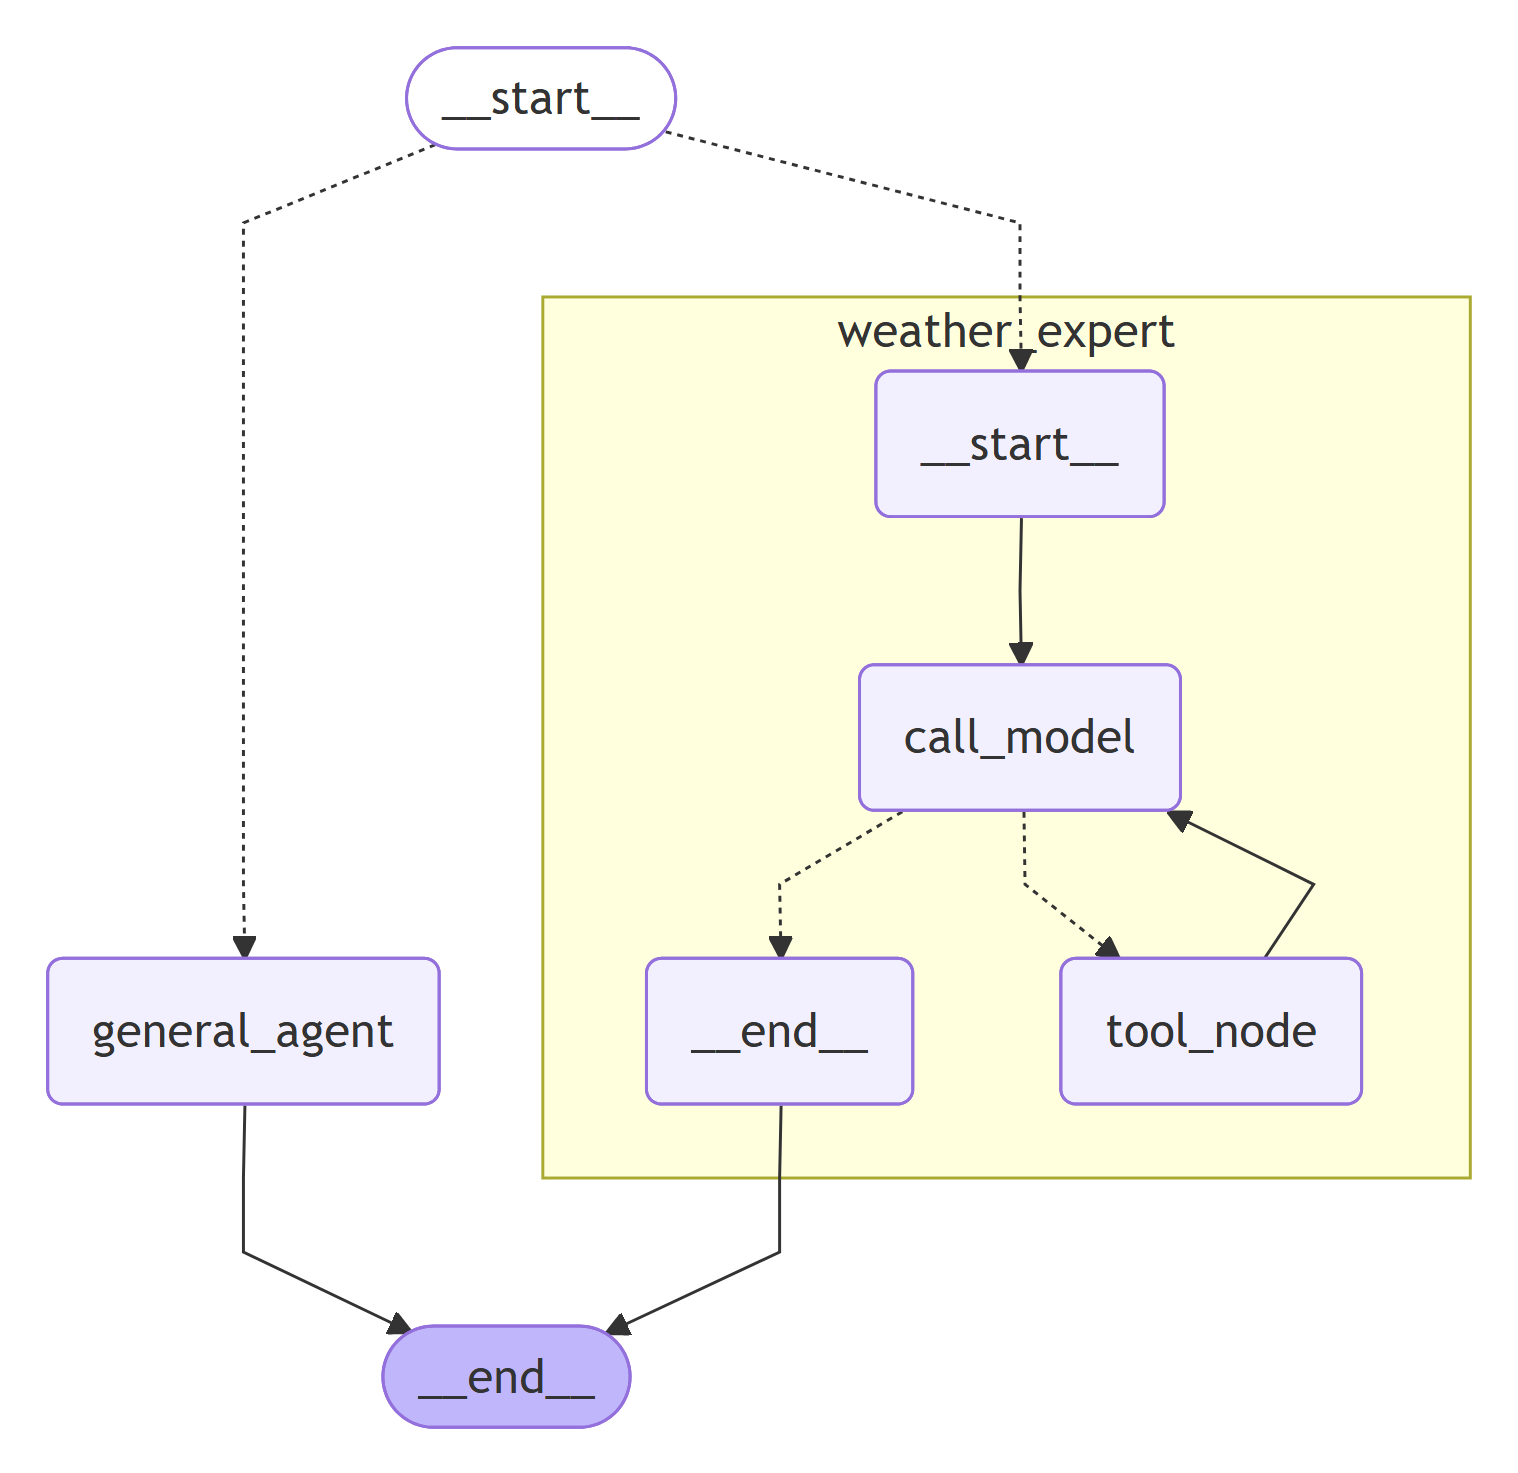

In [ ]:
# [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(main_agent.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [10]:
try:
    display(Image(main_agent.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [11]:
from langchain_core.messages import HumanMessage

query = "부산 날씨 어때?"
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 기상 전문가에게 위임
날씨 조회: 부산


{'messages': [HumanMessage(content='부산 날씨 어때?', additional_kwargs={}, response_metadata={}, id='2ed87f58-23bf-49fc-9cf3-1ae05981c5aa'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city_name": "\\ubd80\\uc0b0"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--31c8155c-0fc7-407f-87ac-556b2e5938e2-0', tool_calls=[{'name': 'get_weather', 'args': {'city_name': '부산'}, 'id': '0076dbcc-ad36-4c69-8ed4-0a359b4c8702', 'type': 'tool_call'}], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"latitude": 35.2, "longitude": 129.0625, "generationtime_ms": 0.07581710815429688, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 26.0, "current_weather_units": {"time": "iso8601", "interval": "sec

In [12]:
result['messages'][-1].content

'현재 부산 날씨는 23.5°C이고, 바람은 초속 12.8km로 불고 있습니다.'

In [13]:
from langchain_core.messages import HumanMessage

query = "랭그래프에 대해 핵심만 간단히 설명해줘."
result = main_agent.invoke({"messages": [HumanMessage(content=query)]})

result

라우팅 결정: 일반 에이전트가 처리


{'messages': [HumanMessage(content='랭그래프에 대해 핵심만 간단히 설명해줘.', additional_kwargs={}, response_metadata={}, id='2f563b22-9f96-48d9-b54d-175b7ace6872'),
  AIMessage(content="랭그래프(LangGraph)는 LLM(대규모 언어 모델) 기반의 복잡한 애플리케이션, 특히 **에이전트(Agent) 워크플로우**를 구축하기 위한 라이브러리입니다.\n\n핵심은 **'상태 기반의 그래프'** 구조를 사용한다는 점입니다.\n\n1.  **그래프 구조:** 마치 플로우차트처럼, 여러 단계(노드)와 그 단계들을 연결하는 흐름(엣지)으로 구성됩니다. 각 단계는 LLM 호출, 도구 사용, 또는 특정 로직 실행 등 하나의 작업을 수행합니다.\n2.  **상태 관리:** 가장 중요한 특징은 워크플로우 진행 중 **'상태(State)'를 기억하고 업데이트**하며, 이 상태에 따라 다음 단계를 동적으로 결정할 수 있다는 것입니다.\n3.  **반복 및 조건:** 이를 통해 이전 대화 내용을 기억하거나, 특정 조건에 따라 다른 경로로 진행하거나, 필요한 정보가 얻어질 때까지 특정 단계를 **반복(루프)**할 수 있는 복잡한 에이전트를 만들 수 있습니다.\n\n간단히 말해, LangGraph는 LLM이 단순한 질의응답을 넘어, **생각하고, 도구를 사용하고, 정보를 수집하며, 스스로 판단하여 목표를 달성하는 복잡한 '지능형 에이전트'**를 만들 수 있게 돕는 도구입니다.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--d66b154d-10b6-49af-9b57-7e17

In [14]:
print(result['messages'][-1].content)

랭그래프(LangGraph)는 LLM(대규모 언어 모델) 기반의 복잡한 애플리케이션, 특히 **에이전트(Agent) 워크플로우**를 구축하기 위한 라이브러리입니다.

핵심은 **'상태 기반의 그래프'** 구조를 사용한다는 점입니다.

1.  **그래프 구조:** 마치 플로우차트처럼, 여러 단계(노드)와 그 단계들을 연결하는 흐름(엣지)으로 구성됩니다. 각 단계는 LLM 호출, 도구 사용, 또는 특정 로직 실행 등 하나의 작업을 수행합니다.
2.  **상태 관리:** 가장 중요한 특징은 워크플로우 진행 중 **'상태(State)'를 기억하고 업데이트**하며, 이 상태에 따라 다음 단계를 동적으로 결정할 수 있다는 것입니다.
3.  **반복 및 조건:** 이를 통해 이전 대화 내용을 기억하거나, 특정 조건에 따라 다른 경로로 진행하거나, 필요한 정보가 얻어질 때까지 특정 단계를 **반복(루프)**할 수 있는 복잡한 에이전트를 만들 수 있습니다.

간단히 말해, LangGraph는 LLM이 단순한 질의응답을 넘어, **생각하고, 도구를 사용하고, 정보를 수집하며, 스스로 판단하여 목표를 달성하는 복잡한 '지능형 에이전트'**를 만들 수 있게 돕는 도구입니다.
